# 1. Get the data

In [117]:
import torch
torch.set_default_device('cuda')
device = torch.device('cuda')


In [118]:
import pandas as pd

df = pd.read_csv('../../../Datasets/TelcoChurn.csv')

How I already have this project in the Machine Learning Folder, i will just use the EDA and Preprocessing methods from, but with deep learning methods

# 2. Preprocessing Methods

In [119]:
# Rename the columns for all lower
df.columns = df.columns.str.lower()

# Drop the null values in the numbers
df['totalcharges'] = pd.to_numeric(df['totalcharges'], errors='coerce')

# 2. REMOVE as linhas que ficaram com NaN (Essencial!)


# Drop the noise features
df_prepared = df.drop(columns=['customerid', 'gender', 'phoneservice', 'multiplelines'])
df_prepared.head()
df_prepared = df_prepared.dropna()
# Encoding (ONEHOT)
binary_cols = [
    'partner', 'dependents', 'paperlessbilling', 'onlinesecurity', 
    'onlinebackup', 'deviceprotection', 'techsupport', 
    'streamingtv', 'streamingmovies', 'churn'
]

for col in binary_cols:
    df_prepared[col] = df_prepared[col].map({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

#  Encoding (ORDINAL)
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df_prepared['contract'] = df_prepared['contract'].map(contract_map)

internet_map = {'No': 0, 'DSL': 1, 'Fiber optic': 2}
df_prepared['internetservice'] = df_prepared['internetservice'].map(internet_map)

df_prepared['paymentmethod'] = df_prepared['paymentmethod'].apply(lambda x: 1 if x == 'Electronic check' else 0)


df_prepared = df_prepared.reset_index(drop=True)

# 3. Split the data

In [120]:
X = df_prepared.drop('churn', axis = 1)
y = df_prepared['churn']


In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# X, Y

X = df_prepared.drop('churn', axis = 1)
y = df_prepared['churn']



# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=43, stratify=y)
print(f'Shape of train: {X_train.shape}, {y_train.shape}')
print(f'Shape of test: {X_test.shape}, {y_test.shape}')


# Scaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Np to Tensor
X_train = torch.tensor(X_train, dtype=torch.float32).to(device=device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device=device)

y_train = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device=device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device=device)

print(f'Shape of train: {X_train.shape}, {y_train.shape}')
print(f'Shape of test: {X_test.shape}, {y_test.shape}')



Shape of train: (5274, 16), (5274,)
Shape of test: (1758, 16), (1758,)
Shape of train: torch.Size([5274, 16]), torch.Size([5274, 1])
Shape of test: torch.Size([1758, 16]), torch.Size([1758, 1])


In [122]:
from torch.utils.data import TensorDataset, DataLoader

train_set = TensorDataset(X_train, y_train)
loader = DataLoader(train_set, batch_size=32, shuffle=True, generator=torch.Generator(device=device))

# 4. Get the Models (I, II and III) and the optim options

In [123]:
import torch.nn as nn
import torch.optim as optim
import torch


class Model(nn.Module):
    def __init__(self, input_dim):
        super(Model, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim,  64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1))

    def forward(self, x):
        return self.model(x)



model = Model(input_dim=X_train.shape[1]).to(device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([2.0]).to(device))
optimizer = optim.Adam(model.parameters(), lr=0.005)
epochs = 100
    

# 5. Train the model

In [124]:
model.train()
for epoch in range(epochs):
    cumulative_loss = 0

    for batch_X, batch_Y in loader:
        # Clear the gradient for the last time
        optimizer.zero_grad()

        # Do the predict
        y_preds = model(batch_X)

        # Calculate the loss
        loss = criterion(y_preds, batch_Y)
        
        # bgackprop
        loss.backward()

        # Update the heights
        optimizer.step()

        # Loss  for the epoch
        cumulative_loss += loss.item()
        
    average_epoch_loss = cumulative_loss / len(loader)
    print(f'=' * 50)
    print(f'Epoch: {epoch + 1} | Loss Média: {average_epoch_loss:.4f}')

Epoch: 1 | Loss Média: 0.6501
Epoch: 2 | Loss Média: 0.6160
Epoch: 3 | Loss Média: 0.6090
Epoch: 4 | Loss Média: 0.6059
Epoch: 5 | Loss Média: 0.6019
Epoch: 6 | Loss Média: 0.5939
Epoch: 7 | Loss Média: 0.5920
Epoch: 8 | Loss Média: 0.5920
Epoch: 9 | Loss Média: 0.5862
Epoch: 10 | Loss Média: 0.5827
Epoch: 11 | Loss Média: 0.5758
Epoch: 12 | Loss Média: 0.5734
Epoch: 13 | Loss Média: 0.5660
Epoch: 14 | Loss Média: 0.5677
Epoch: 15 | Loss Média: 0.5580
Epoch: 16 | Loss Média: 0.5592
Epoch: 17 | Loss Média: 0.5508
Epoch: 18 | Loss Média: 0.5411
Epoch: 19 | Loss Média: 0.5371
Epoch: 20 | Loss Média: 0.5282
Epoch: 21 | Loss Média: 0.5262
Epoch: 22 | Loss Média: 0.5182
Epoch: 23 | Loss Média: 0.5152
Epoch: 24 | Loss Média: 0.5059
Epoch: 25 | Loss Média: 0.4968
Epoch: 26 | Loss Média: 0.4902
Epoch: 27 | Loss Média: 0.4889
Epoch: 28 | Loss Média: 0.4810
Epoch: 29 | Loss Média: 0.4760
Epoch: 30 | Loss Média: 0.4666
Epoch: 31 | Loss Média: 0.4585
Epoch: 32 | Loss Média: 0.4530
Epoch: 33 | Loss 

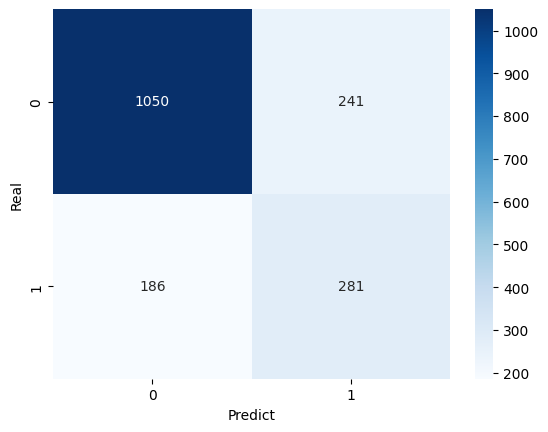

              precision    recall  f1-score   support

         0.0       0.85      0.81      0.83      1291
         1.0       0.54      0.60      0.57       467

    accuracy                           0.76      1758
   macro avg       0.69      0.71      0.70      1758
weighted avg       0.77      0.76      0.76      1758



In [126]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
with torch.no_grad():

    outputs = model(X_test)

    predicted = (torch.sigmoid(outputs) > 0.5).float()

cm = confusion_matrix(y_test.cpu(), predicted.cpu())
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predict')
plt.ylabel('Real')
plt.show()
print(classification_report(y_test.cpu(), predicted.cpu()))